In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#df1 = customer_data
#df2 = sales_data

df1=pd.read_csv("C:/datasets/customer_data.csv")
df2=pd.read_csv("C:/datasets/sales_data.csv")
print(df1.head(5))
print(df1.tail(5))




  customer_id  gender   age payment_method
0     C241288  Female  28.0    Credit Card
1     C111565    Male  21.0     Debit Card
2     C266599    Male  20.0           Cash
3     C988172  Female  66.0    Credit Card
4     C189076  Female  53.0           Cash
      customer_id  gender   age payment_method
99452     C441542  Female  45.0    Credit Card
99453     C569580    Male  27.0           Cash
99454     C103292    Male  63.0     Debit Card
99455     C800631    Male  56.0           Cash
99456     C273973  Female  36.0    Credit Card


In [2]:
print(df2.head(3))
print(df2.tail(3))

  invoice_no customer_id  category  quantity    price invoice_date  \
0    I138884     C241288  Clothing         5  1500.40   05-08-2022   
1    I317333     C111565     Shoes         3  1800.51   12-12-2021   
2    I127801     C266599  Clothing         1   300.08   09-11-2021   

    shopping_mall  
0          Kanyon  
1  Forum Istanbul  
2       Metrocity  
      invoice_no customer_id         category  quantity    price invoice_date  \
99454    I824010     C103292  Food & Beverage         2    10.46   28-03-2021   
99455    I702964     C800631       Technology         4  4200.00   16-03-2021   
99456    I232867     C273973         Souvenir         3    35.19   15-10-2022   

          shopping_mall  
99454         Metrocity  
99455      Istinye Park  
99456  Mall of Istanbul  


In [3]:
#rows & columns

print("df1 :",df1.shape)
print("df2 :",df2.shape)
print("\n")
#columns
print("df1 col :",df1.columns)
print("df2 col :",df2.columns)
print("\n")
#dtype
print(df1.dtypes)
print("\n")
print(df2.dtypes)



df1 : (99457, 4)
df2 : (99457, 7)


df1 col : Index(['customer_id', 'gender', 'age', 'payment_method'], dtype='object')
df2 col : Index(['invoice_no', 'customer_id', 'category', 'quantity', 'price',
       'invoice_date', 'shopping_mall'],
      dtype='object')


customer_id        object
gender             object
age               float64
payment_method     object
dtype: object


invoice_no        object
customer_id       object
category          object
quantity           int64
price            float64
invoice_date      object
shopping_mall     object
dtype: object


In [4]:
#statistics
print("customer_data")
print(df1.describe())
print("sales_data")
print(df2.describe())

customer_data
                age
count  99338.000000
mean      43.425859
std       14.989400
min       18.000000
25%       30.000000
50%       43.000000
75%       56.000000
max       69.000000
sales_data
           quantity         price
count  99457.000000  99457.000000
mean       3.003429    689.256321
std        1.413025    941.184567
min        1.000000      5.230000
25%        2.000000     45.450000
50%        3.000000    203.300000
75%        4.000000   1200.320000
max        5.000000   5250.000000


In [5]:
#missing values
print("customer_data")
print(df1.isnull().sum())
print("\n")
print("sales_data")
print(df2.isnull().sum())

customer_data
customer_id         0
gender              0
age               119
payment_method      0
dtype: int64


sales_data
invoice_no       0
customer_id      0
category         0
quantity         0
price            0
invoice_date     0
shopping_mall    0
dtype: int64


In [6]:
#duplicate columns
print("No of duplicates in df1 :",df1.duplicated().sum())
print("No of duplicates in df2 :",df2.duplicated().sum())




No of duplicates in df1 : 0
No of duplicates in df2 : 0


In [7]:
#categorical columns for df1
cat_col=df1.select_dtypes(include="object").columns
print(cat_col)

for col in cat_col:
    print(col)
    print(df1[col].unique())

print("\n")
cat_col2=df2.select_dtypes(include="object").columns
print(cat_col2)

for col in cat_col2:
    print(col)
    print(df2[col].unique())

Index(['customer_id', 'gender', 'payment_method'], dtype='object')
customer_id
['C241288' 'C111565' 'C266599' ... 'C103292' 'C800631' 'C273973']
gender
['Female' 'Male']
payment_method
['Credit Card' 'Debit Card' 'Cash']


Index(['invoice_no', 'customer_id', 'category', 'invoice_date',
       'shopping_mall'],
      dtype='object')
invoice_no
['I138884' 'I317333' 'I127801' ... 'I824010' 'I702964' 'I232867']
customer_id
['C241288' 'C111565' 'C266599' ... 'C103292' 'C800631' 'C273973']
category
['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']
invoice_date
['05-08-2022' '12-12-2021' '09-11-2021' '16-05-2021' '24-10-2021'
 '24-05-2022' '13-03-2022' '13-01-2021' '04-11-2021' '22-08-2021'
 '25-12-2022' '28-10-2022' '31-07-2022' '17-11-2022' '03-06-2022'
 '07-11-2021' '16-01-2021' '05-01-2022' '26-07-2021' '07-03-2023'
 '15-02-2023' '01-05-2021' '18-06-2022' '26-10-2021' '16-12-2022'
 '20-04-2022' '10-10-2022' '23-08-2022' '29-04-2021' '04-07-2022'
 '

In [8]:
#invoice_date format change
df2["invoice_date"]=pd.to_datetime(df2["invoice_date"],format="mixed")
print(df2["invoice_date"].head(10).dtype)

datetime64[ns]


In [9]:
df3=pd.merge(df1,df2,on="customer_id")
print(df3.head(10))

  customer_id  gender   age payment_method invoice_no   category  quantity  \
0     C241288  Female  28.0    Credit Card    I138884   Clothing         5   
1     C111565    Male  21.0     Debit Card    I317333      Shoes         3   
2     C266599    Male  20.0           Cash    I127801   Clothing         1   
3     C988172  Female  66.0    Credit Card    I173702      Shoes         5   
4     C189076  Female  53.0           Cash    I337046      Books         4   
5     C657758  Female  28.0    Credit Card    I227836   Clothing         5   
6     C151197  Female  49.0           Cash    I121056  Cosmetics         1   
7     C176086  Female  32.0    Credit Card    I293112   Clothing         2   
8     C159642    Male  69.0    Credit Card    I293455   Clothing         3   
9     C283361  Female  60.0    Credit Card    I326945   Clothing         2   

     price invoice_date     shopping_mall  
0  1500.40   2022-05-08            Kanyon  
1  1800.51   2021-12-12    Forum Istanbul  
2   300.0

In [10]:
#missing_customer
missing_customer=df2[~df2["customer_id"].isin(df1["customer_id"])]
print(missing_customer)

Empty DataFrame
Columns: [invoice_no, customer_id, category, quantity, price, invoice_date, shopping_mall]
Index: []


In [11]:
df3['age']=df3['age'].fillna(method='bfill')
new=df3['age'].isnull()
print(new.sum())


0


C:\Users\deepa\AppData\Local\Temp\ipykernel_3524\1407368802.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df3['age']=df3['age'].fillna(method='bfill')


In [12]:
#check zero or negative value in df3
count=(df3['price']<=0).sum()
print("zeros and -ve value : ",count)

#New column Total_sales
df3["Total_sales"]=df3["quantity"]*df3["price"]
print(df3)



zeros and -ve value :  0
      customer_id  gender   age payment_method invoice_no         category  \
0         C241288  Female  28.0    Credit Card    I138884         Clothing   
1         C111565    Male  21.0     Debit Card    I317333            Shoes   
2         C266599    Male  20.0           Cash    I127801         Clothing   
3         C988172  Female  66.0    Credit Card    I173702            Shoes   
4         C189076  Female  53.0           Cash    I337046            Books   
...           ...     ...   ...            ...        ...              ...   
99452     C441542  Female  45.0    Credit Card    I219422         Souvenir   
99453     C569580    Male  27.0           Cash    I325143  Food & Beverage   
99454     C103292    Male  63.0     Debit Card    I824010  Food & Beverage   
99455     C800631    Male  56.0           Cash    I702964       Technology   
99456     C273973  Female  36.0    Credit Card    I232867         Souvenir   

       quantity    price invoice_date 

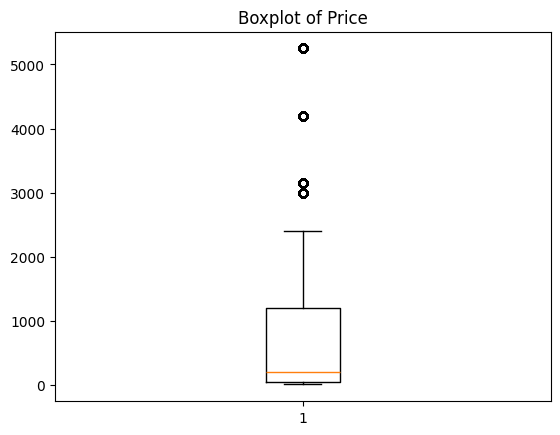

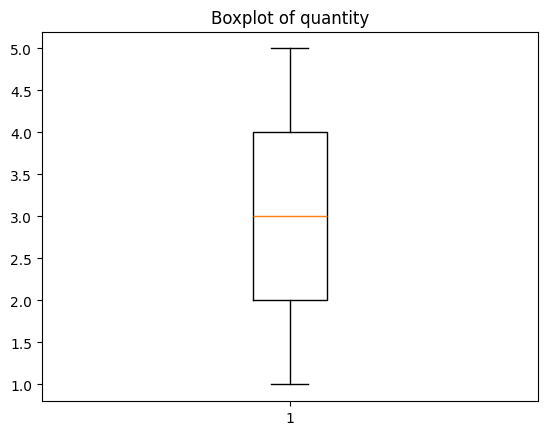

In [13]:

plt.boxplot(df3["price"])
plt.title("Boxplot of Price")
plt.show()


plt.boxplot(df3["quantity"])
plt.title("Boxplot of quantity")
plt.show()

In [14]:
#customer based upon gender
customer=df3.groupby("gender")['customer_id'].count()
print("customer based upon gender")
print(customer)

customer based upon gender
gender
Female    59482
Male      39975
Name: customer_id, dtype: int64


In [15]:
#average
average_price=df3["price"].mean()
print("averge_price :",round(average_price))

averge_price : 689


In [16]:
#average quantity
avg_quantity=df3['quantity'].mean()
print("avg-quantity :",round(avg_quantity))

avg-quantity : 3


In [17]:
#most often paymnet method
payment_method=df3.groupby("payment_method")['customer_id'].count()
print(payment_method.head(1))

payment_method
Cash    44447
Name: customer_id, dtype: int64


In [18]:
#highest transaction mall
mall_transaction=df3.groupby("shopping_mall")["invoice_no"].count()
print(mall_transaction.idxmax())

Mall of Istanbul


In [19]:
#Most appeared category
category=(df3["category"].value_counts())
print(category.head(1))

category
Clothing    34487
Name: count, dtype: int64


In [20]:
# distribution of Customer ages
ages=df3['age'].value_counts().sort_index()
print(ages.head())

age
18.0    1843
19.0    1930
20.0    1844
21.0    1945
22.0    2050
Name: count, dtype: int64


In [21]:
# Money spend as per gender
money_spend=df3.groupby("gender")['Total_sales'].sum()
print(round(money_spend).head(1))

gender
Female    150207136.0
Name: Total_sales, dtype: float64


In [22]:
#payment_amt based on methods
payment_system=df3.groupby("payment_method")["Total_sales"].sum()
print(round(payment_system).head(1))

payment_method
Cash    112832243.0
Name: Total_sales, dtype: float64


In [23]:
#highest sales based on total_sales
highest_sales=df3.groupby("shopping_mall")["Total_sales"].sum().sort_values(ascending=False)
print(highest_sales.head(1))

shopping_mall
Mall of Istanbul    50872481.68
Name: Total_sales, dtype: float64


In [24]:
#highest sales in category
print((df3['category'].unique()))
category=df3.groupby('category')["Total_sales"].sum().sort_values(ascending=False)
print(round(category).head(1))

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']
category
Clothing    113996791.0
Name: Total_sales, dtype: float64


In [25]:
# highest average order value based on category
avg_order=df3.groupby("category")["Total_sales"].mean().sort_values(ascending=False)
print(avg_order.head(1))

category
Technology    11581.735388
Name: Total_sales, dtype: float64


In [26]:
#highest product category in Female
female=df3[df3["gender"]=="Female"]
female.groupby(["gender","category"])["quantity"].sum().sort_values(ascending=False).head(1)



gender  category
Female  Clothing    62039
Name: quantity, dtype: int64

In [27]:
#highest product category in Male

Male=df3[df3["gender"]=="Male"]
Male.groupby(["gender","category"])["quantity"].sum().sort_values(ascending=False).head(1)




gender  category
Male    Clothing    41519
Name: quantity, dtype: int64

In [28]:
#highest sales based upon quantity
print(df3.groupby("shopping_mall")['quantity'].sum().sort_values(ascending=False).head(1))


shopping_mall
Mall of Istanbul    60114
Name: quantity, dtype: int64


payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64


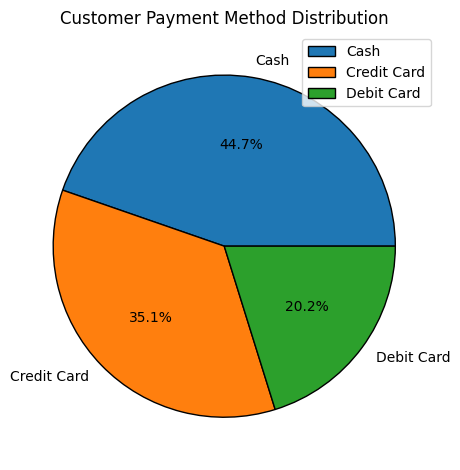

In [29]:
#Payment method distribution
payment_dist=(df3["payment_method"].value_counts())
print(payment_dist)

plt.Figure(figsize=(6,4))
plt.pie(payment_dist.values,labels=payment_dist.index,autopct="%1.1f%%",wedgeprops={"edgecolor":"black"})
plt.title("Customer Payment Method Distribution")
plt.legend()
plt.tight_layout()
plt.show()

gender
Female    59482
Male      39975
Name: count, dtype: int64


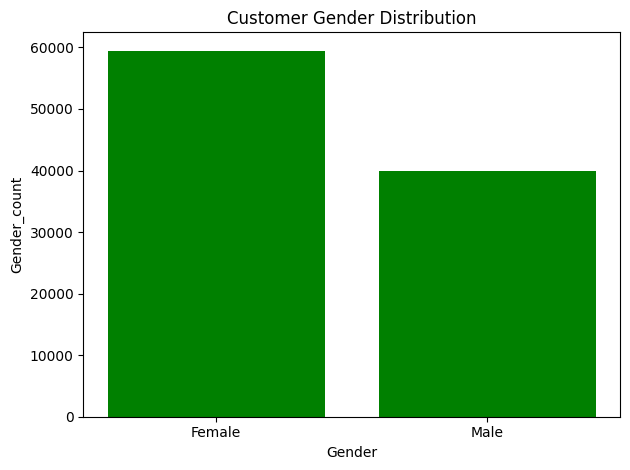

In [30]:
#Gender distribution
gender_dist=(df3['gender'].value_counts())
print(gender_dist)

plt.Figure(figsize=(6,5))
plt.bar(gender_dist.index,gender_dist.values,color="green")
plt.xlabel('Gender')
plt.ylabel("Gender_count")
plt.title('Customer Gender Distribution')

plt.tight_layout()
plt.show()


category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64


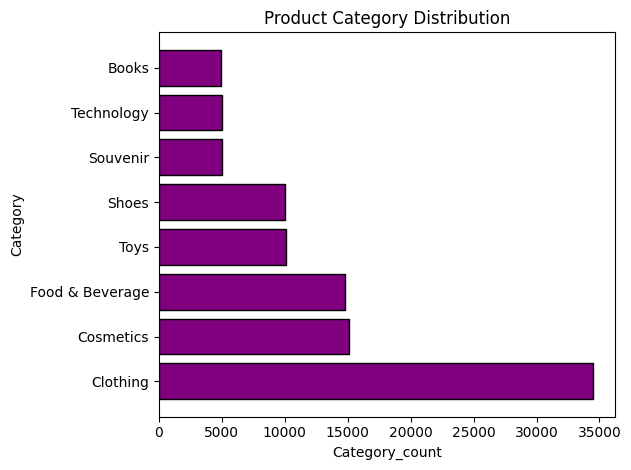

In [31]:
#Product category distribution
category_dist=(df3['category'].value_counts())
print(category_dist)

plt.Figure(figsize=(8,5))
plt.barh(category_dist.index,category_dist.values,color='purple',edgecolor='black')
plt.xlabel('Category_count')
plt.ylabel("Category")
plt.title("Product Category Distribution")
plt.tight_layout()
plt.show()

category
Books                 834553.0
Clothing           113996791.0
Cosmetics            6792863.0
Food & Beverage       849535.0
Shoes               66553451.0
Souvenir              635825.0
Technology          57862350.0
Toys                 3980426.0
Name: Total_revenue, dtype: float64


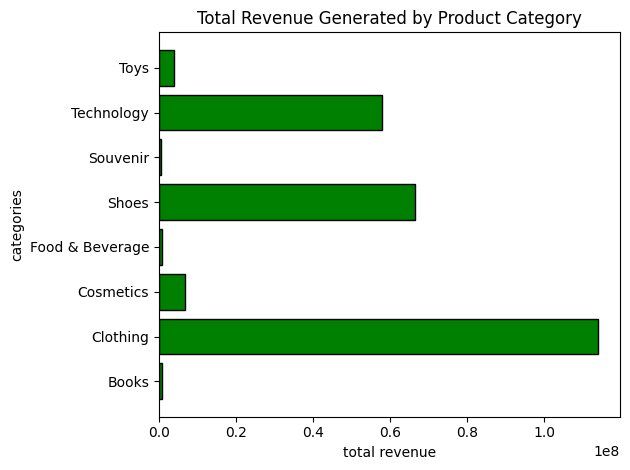

In [32]:
#Revenue by category
df3.rename(columns={"Total_sales":'Total_revenue'},inplace=True)

Category_by_revenue=df3.groupby('category')['Total_revenue'].sum().round()
print(Category_by_revenue)

plt.barh(Category_by_revenue.index,Category_by_revenue.values,color='green',edgecolor='black')
plt.ylabel('categories')
plt.xlabel('total revenue')
plt.title('Total Revenue Generated by Product Category')
plt.tight_layout()
plt.show()

In [33]:


category_summary=df3.groupby('category').agg(Total_revenue=("Total_revenue",'sum'),Total_quantity=("quantity",'sum')).round()
print(category_summary)


"""Cosmetics, Food & Beverage, and Toys have high sales volumes but generate relatively lower revenue compared to the top-performing categories. In contrast, 
Technology and Souvenir sell fewer units but generate higher revenue per unit sold.
Promoting these three high-volume categories through targeted marketing, product bundling, 
or upselling strategies could help increase their overall revenue contribution."""

                 Total_revenue  Total_quantity
category                                      
Books                 834553.0           14982
Clothing           113996791.0          103558
Cosmetics            6792863.0           45465
Food & Beverage       849535.0           44277
Shoes               66553451.0           30217
Souvenir              635825.0           14871
Technology          57862350.0           15021
Toys                 3980426.0           30321


'Cosmetics, Food & Beverage, and Toys have high sales volumes but generate relatively lower revenue compared to the top-performing categories. In contrast, \nTechnology and Souvenir sell fewer units but generate higher revenue per unit sold.\nPromoting these three high-volume categories through targeted marketing, product bundling, \nor upselling strategies could help increase their overall revenue contribution.'

In [34]:

mall_info=df3.groupby('shopping_mall').agg(Total_revenue=('Total_revenue','sum'),Total_quantity=("quantity","sum"))
print(mall_info.sort_values(ascending=False,by='Total_revenue').head(1))


"""Mall of Istanbul is the best-performing shopping mall, generating the highest total revenue among all locations. It also records a high sales volume, indicating strong customer purchasing activity. Based on the available data, this mall makes the largest contribution to the company's overall sales performance."""

                  Total_revenue  Total_quantity
shopping_mall                                  
Mall of Istanbul    50872481.68           60114


"Mall of Istanbul is the best-performing shopping mall, generating the highest total revenue among all locations. It also records a high sales volume, indicating strong customer purchasing activity. Based on the available data, this mall makes the largest contribution to the company's overall sales performance."

In [35]:
payment_info=df3.groupby('payment_method').agg(Total_revenue=("Total_revenue","sum"),Total_quantity=('quantity',"sum")).round()
print(payment_info)


"""Debit Card records the lowest total revenue and sales quantity among all payment methods, indicating that it is the least preferred option for customers. Based on the available data, the company should prioritize the payment method with the highest customer usage and revenue contribution. If the business aims to increase debit card adoption, it should first investigate the reasons behind its low usage before investing in promotional campaigns."""


                Total_revenue  Total_quantity
payment_method                               
Cash              112832243.0          133370
Credit Card        88077124.0          105045
Debit Card         50596427.0           60297


'Debit Card records the lowest total revenue and sales quantity among all payment methods, indicating that it is the least preferred option for customers. Based on the available data, the company should prioritize the payment method with the highest customer usage and revenue contribution. If the business aims to increase debit card adoption, it should first investigate the reasons behind its low usage before investing in promotional campaigns.'